In [1]:
import pandas as pd
from pathlib import Path

labels_path = Path("../data/processed/amazon_llm_labels.csv")
human_path = Path("../data/processed/amazon_labeling_100.csv")

llm_df = pd.read_csv(labels_path)
human_df = pd.read_csv(human_path)

print("LLM labels:", len(llm_df))
print("Human labels:", len(human_df))

llm_df.head()

LLM labels: 467
Human labels: 100


,tweet_id,created_at,text,llm_intent
0,420949,2017-10-10 07:58:25+00:00,@AmazonHelp with a new email address. Please w...,account_access
1,17262,2017-10-20 11:36:09+00:00,"@AmazonHelp one order, two consignments. one d...",delivery_issue
2,1343575,2017-10-27 16:42:54+00:00,@AmazonHelp It was @115830 I meant to moan abo...,delivery_issue
3,1381857,2017-11-10 03:34:20+00:00,@AmazonHelp i was never worried about delivery...,delivery_issue
4,2562034,2017-11-17 11:05:43+00:00,@AmazonHelp Hi - this has just happened again ...,delivery_issue


In [3]:
print("LLM columns:")
print(llm_df.columns.tolist())

print("\nLLM shape:")
print(llm_df.shape)

print("\nFirst 5 rows:")
display(llm_df.head())

LLM columns:
['tweet_id', 'created_at', 'text', 'llm_intent']

LLM shape:
(467, 4)

First 5 rows:


,tweet_id,created_at,text,llm_intent
0,420949,2017-10-10 07:58:25+00:00,@AmazonHelp with a new email address. Please w...,account_access
1,17262,2017-10-20 11:36:09+00:00,"@AmazonHelp one order, two consignments. one d...",delivery_issue
2,1343575,2017-10-27 16:42:54+00:00,@AmazonHelp It was @115830 I meant to moan abo...,delivery_issue
3,1381857,2017-11-10 03:34:20+00:00,@AmazonHelp i was never worried about delivery...,delivery_issue
4,2562034,2017-11-17 11:05:43+00:00,@AmazonHelp Hi - this has just happened again ...,delivery_issue


In [4]:
llm_distribution = (
    llm_df["llm_intent"]
    .value_counts()
    .sort_values(ascending=False)
)

print("LLM Intent Distribution:")
print(llm_distribution)

LLM Intent Distribution:
llm_intent
delivery_issue                  120
other_support                    77
refund                           40
return_replacement               32
account_access                   27
order_status                     27
payment_billing                  26
order_cancellation               26
seller_marketplace               22
product_issue                    21
product_availability_pricing     19
prime_membership                 16
delivery_address_options         14
Name: count, dtype: int64


<Axes: title={'center': 'LLM-Generated Intent Distribution'}, xlabel='llm_intent'>

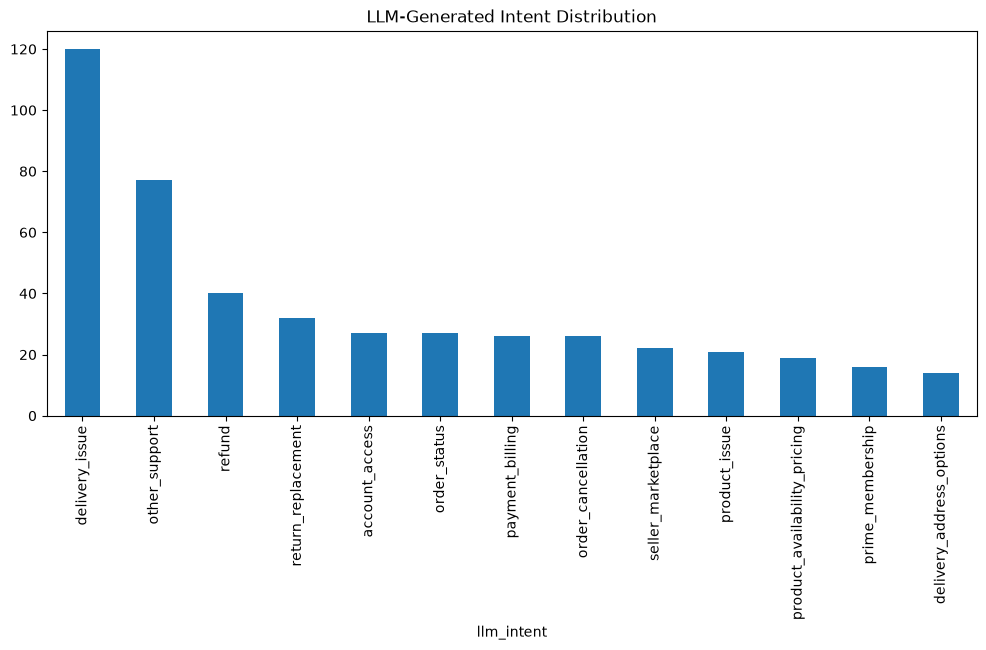

In [5]:
llm_distribution.plot(
    kind="bar",
    figsize=(12, 5),
    title="LLM-Generated Intent Distribution"
)

In [6]:
valid_intents = {
    "order_status",
    "delivery_issue",
    "delivery_address_options",
    "order_cancellation",
    "return_replacement",
    "refund",
    "product_issue",
    "payment_billing",
    "account_access",
    "prime_membership",
    "seller_marketplace",
    "product_availability_pricing",
    "installation_service",
    "other_support"
}

invalid_labels = llm_df[
    ~llm_df["llm_intent"].isin(valid_intents)
]

print("Invalid labels:", len(invalid_labels))

if len(invalid_labels) > 0:
    display(invalid_labels)

Invalid labels: 0


In [7]:
validation_sample = (
    llm_df
    .sample(n=min(50, len(llm_df)), random_state=42)
    [["tweet_id", "created_at", "text", "llm_intent"]]
    .reset_index(drop=True)
)

validation_sample["human_intent"] = ""
validation_sample["correct"] = ""

display(validation_sample)

,tweet_id,created_at,text,llm_intent,human_intent,correct
0,1598691,2017-10-17 13:14:23+00:00,@AmazonHelp Refund shows on the order. How and...,refund,,
1,1735204,2017-11-07 14:16:49+00:00,@AmazonHelp That worked! Thank you!,other_support,,
2,1734598,2017-11-10 09:53:33+00:00,@AmazonHelp There's only a security guard on d...,delivery_issue,,
3,498388,2017-12-01 19:33:11+00:00,@AmazonHelp Couriers just throw the parcel at ...,delivery_issue,,
4,689477,2017-11-25 10:29:58+00:00,"@AmazonHelp I ordered a product in July 2017, ...",return_replacement,,
5,739044,2017-10-11 13:09:32+00:00,"@AmazonHelp No, I've tried 8 times today to ge...",account_access,,
6,1791566,2017-11-18 15:37:51+00:00,@AmazonHelp It is a third party vendor namely ...,seller_marketplace,,
7,580551,2017-12-03 12:45:36+00:00,@AmazonHelp Frustratingly only the big lamp is...,return_replacement,,
8,1087656,2017-10-25 12:50:07+00:00,@AmazonHelp Anche a me è non sai quanto. Ti ri...,other_support,,
9,2422787,2017-11-14 19:00:16+00:00,"@AmazonHelp Well, that may be true for a newly...",product_availability_pricing,,


In [8]:
validation_path = "../data/processed/amazon_llm_validation_50.csv"

validation_sample.to_csv(
    validation_path,
    index=False
)

print(f"Saved validation sample to: {validation_path}")

Saved validation sample to: ../data/processed/amazon_llm_validation_50.csv


In [10]:
validation_df = pd.read_csv(
    "../data/processed/amazon_llm_validation_50.csv"
)

In [11]:
import pandas as pd

validation_df = pd.read_csv(
    "../data/processed/amazon_llm_validation_50_completed.csv"
)

print("Rows:", len(validation_df))
print("Columns:", validation_df.columns.tolist())

display(validation_df.head())

Rows: 50
Columns: ['tweet_id', 'created_at', 'text', 'llm_intent', 'human_intent', 'correct']


,tweet_id,created_at,text,llm_intent,human_intent,correct
0,1598691,2017-10-17 13:14:23+00:00,@AmazonHelp Refund shows on the order. How and...,refund,refund,True
1,1735204,2017-11-07 14:16:49+00:00,@AmazonHelp That worked! Thank you!,other_support,other_support,True
2,1734598,2017-11-10 09:53:33+00:00,@AmazonHelp There's only a security guard on d...,delivery_issue,delivery_issue,True
3,498388,2017-12-01 19:33:11+00:00,@AmazonHelp Couriers just throw the parcel at ...,delivery_issue,delivery_issue,True
4,689477,2017-11-25 10:29:58+00:00,"@AmazonHelp I ordered a product in July 2017, ...",return_replacement,return_replacement,True


In [12]:
disagreements = validation_df[
    validation_df["llm_intent"] != validation_df["human_intent"]
].copy()

print("Disagreements:", len(disagreements))

display(
    disagreements[
        ["tweet_id", "text", "llm_intent", "human_intent"]
    ]
)

Disagreements: 4


,tweet_id,text,llm_intent,human_intent
10,1313423,@AmazonHelp There is one left. By the time I g...,refund,product_availability_pricing
12,1719697,@AmazonHelp Payment done already,other_support,payment_billing
15,2378939,@AmazonHelp 16th-24th. simply expressing conce...,order_status,product_availability_pricing
25,364046,@AmazonHelp I would be great to have GPS track...,other_support,delivery_address_options


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    validation_df["human_intent"],
    validation_df["llm_intent"],
    zero_division=0
))

                              precision    recall  f1-score   support

              account_access       1.00      1.00      1.00         4
    delivery_address_options       1.00      0.67      0.80         3
              delivery_issue       1.00      1.00      1.00        12
          order_cancellation       1.00      1.00      1.00         1
                order_status       0.75      1.00      0.86         3
               other_support       0.78      1.00      0.88         7
             payment_billing       1.00      0.67      0.80         3
            prime_membership       1.00      1.00      1.00         1
product_availability_pricing       1.00      0.60      0.75         5
                      refund       0.88      1.00      0.93         7
          return_replacement       1.00      1.00      1.00         2
          seller_marketplace       1.00      1.00      1.00         2

                    accuracy                           0.92        50
                  

In [14]:
cm = confusion_matrix(
    validation_df["human_intent"],
    validation_df["llm_intent"],
    labels=sorted(validation_df["human_intent"].unique())
)

print(cm)

[[ 4  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  0  0  0  1  0  0  0  0  0  0]
 [ 0  0 12  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  3  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  7  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  2  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  3  1  0  0]
 [ 0  0  0  0  0  0  0  0  0  7  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  2  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  2]]
